# Naive Bayes

## Import librairies and dataset

In [ ]:
# %pip install pandas seaborn matplotlib scikit-learn gensim eli5 tiktoken spacy

: 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from datasets import load_dataset
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
import tiktoken

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier

from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop

In [3]:
df = pd.read_csv("MovieDataThread.csv")
df.head()

,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,tmdb_id,tmdb_music,tmdb_mystery,tmdb_romance,tmdb_science fiction,tmdb_thriller,tmdb_tv movie,tmdb_war,tmdb_western,imdb_adult
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29848.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"1\n Well, now, the Himalay as...\n Well, we in...",Beyond the Edge (2013),NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,...,211088.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This is the main street of the\n town of Loyal...,Beyond the Forest (1949),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,35896.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,397981.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"1\n - Paul.\n Paul, where are you?\n Paul.\n P...",Beyond the Gates of Hell (2022),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28635.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


## Preprocessing and visualization

Convert code to emotion class according to the annotation guideline : https://dreams.ucsc.edu/Coding/emotions.html

In [8]:
# df = df[~df["imdb_id"].isnull()]
# df = df[df.columns.drop(list(df.filter(regex='tmdb_')))]
# list(df.filter(regex='tmdb_').columns)
df_tmdb_not_null = df[~df.filter(like='tmdb_').isnull().all(axis=1)]
df_imdb_not_null = df[~df.filter(like='imdb_').isnull().all(axis=1)]
print("imdb id null with genre " + str(len(df_imdb_not_null[df_imdb_not_null["imdb_id"].isnull()])))
print("tmdb id null with genre " + str(len(df_tmdb_not_null[df_tmdb_not_null["tmdb_id"].isnull()])))

imdb id null with genre 0
tmdb id null with genre 0


In [9]:
numeric_cols = df.filter(like='imdb_').select_dtypes(include=['number'])
df["genre"] = numeric_cols.idxmin(axis=1)

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_81043/1485732757.py:2: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df["genre"] = numeric_cols.idxmin(axis=1)


In [10]:
len(df[df["imdb_id"].isnull()])
# len(df[df.filter(like='tmdb_').isnull().all(axis=1)])

822

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_70571/1616342445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


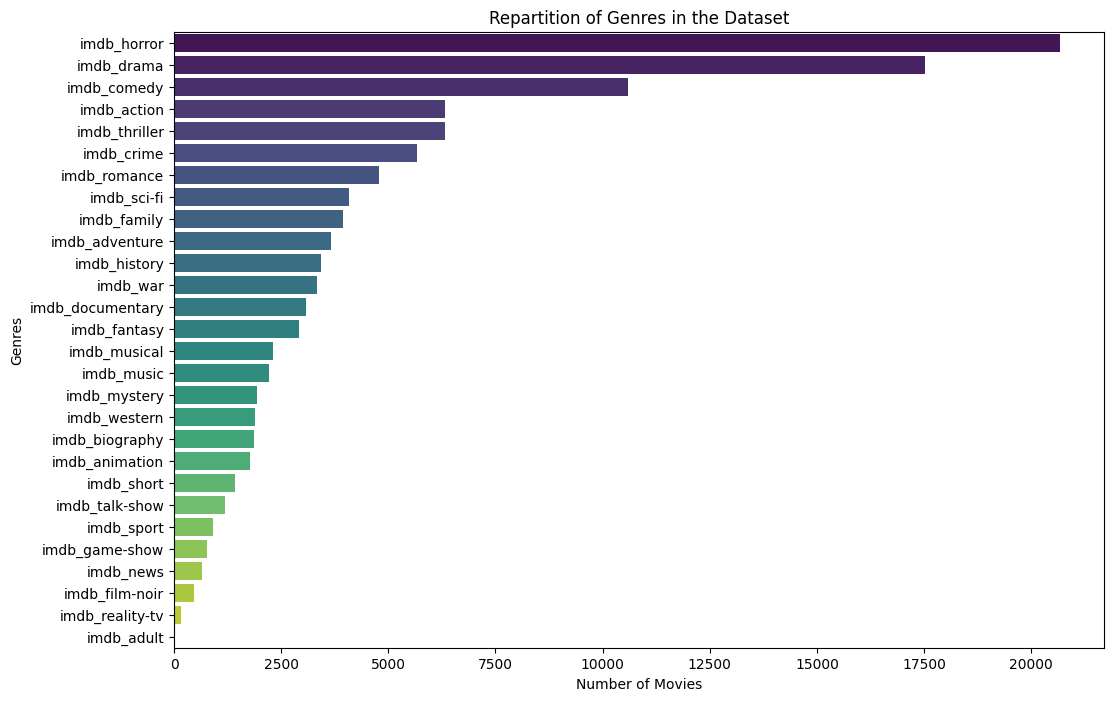

In [6]:
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
genre_counts = genre_counts.drop('imdb_id')

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.xlabel('Number of Movies')
plt.ylabel('Genres')
plt.title('Repartition of Genres in the Dataset')
plt.show()

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_70571/1672658869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts_only_first.values, y=genre_counts_only_first.index, palette="viridis")


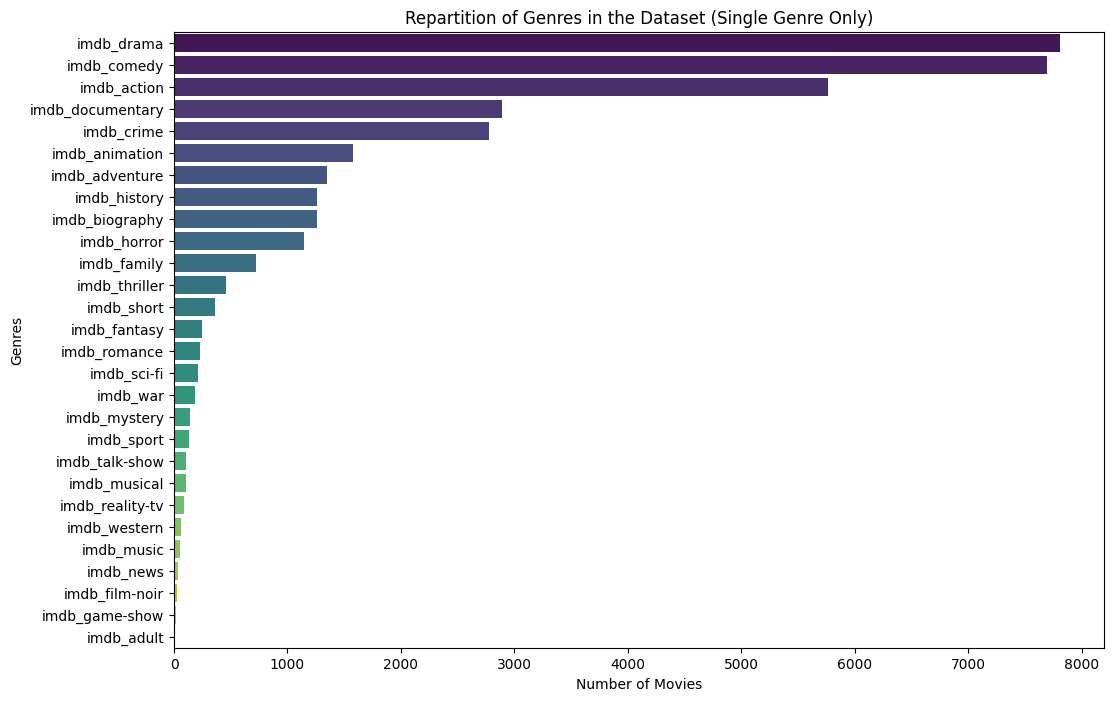

In [7]:
genre_counts_only_first = df[df.filter(like='imdb_') == 1].count().sort_values(ascending=False)
genre_counts_only_first = genre_counts_only_first.drop('imdb_id')
genre_counts_only_first = genre_counts_only_first.filter(like='imdb_')

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts_only_first.values, y=genre_counts_only_first.index, palette="viridis")
plt.xlabel('Number of Movies')
plt.ylabel('Genres')
plt.title('Repartition of Genres in the Dataset (Single Genre Only)')
plt.show()

In [8]:
# Split genre_count into quartiles
genre_counts_quartiles = genre_counts_only_first.quantile([0.25, 0.5, 0.75])

# Select genres that are in the top quartile
top_genres = genre_counts_only_first[genre_counts_only_first >= genre_counts_quartiles[0.75]].index
df_add_to_top = df.copy()

def sort_top(top_genres, df):
    top_genres = top_genres.sort_values(ascending=True, key=lambda x: df[x].count())
    return top_genres
top_genres = sort_top(top_genres, df_add_to_top)
top_genres

Index(['imdb_animation', 'imdb_documentary', 'imdb_adventure', 'imdb_crime',
       'imdb_action', 'imdb_comedy', 'imdb_drama'],
      dtype='object')

In [11]:
top_genres
def add_to_top_genres(row):
    global top_genres
    if row["genre"] not in top_genres:
        for g_top in top_genres:
            if row[g_top] >= 1:
                row["genre"] = g_top
                top_genres = sort_top(top_genres, df_add_to_top)
                break
    return row

df_add_to_top = df_add_to_top.apply(add_to_top_genres, axis=1)
df_add_to_top["genre"].value_counts()

genre
imdb_drama          8802
imdb_comedy         7902
imdb_action         5797
imdb_crime          2989
imdb_documentary    2897
imdb_animation      1641
imdb_horror         1483
imdb_adventure      1364
imdb_history        1257
imdb_family          718
imdb_thriller        454
imdb_id              398
imdb_fantasy         243
imdb_romance         225
imdb_sci-fi          194
imdb_war             178
imdb_short           163
imdb_mystery         137
imdb_talk-show       106
imdb_musical         104
imdb_music            70
imdb_sport            62
imdb_biography        51
imdb_news             38
imdb_reality-tv       28
imdb_film-noir        25
imdb_game-show        17
imdb_adult             1
Name: count, dtype: int64

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_70571/3631647607.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_top_counts.values, y=genre_top_counts.index, palette="viridis")


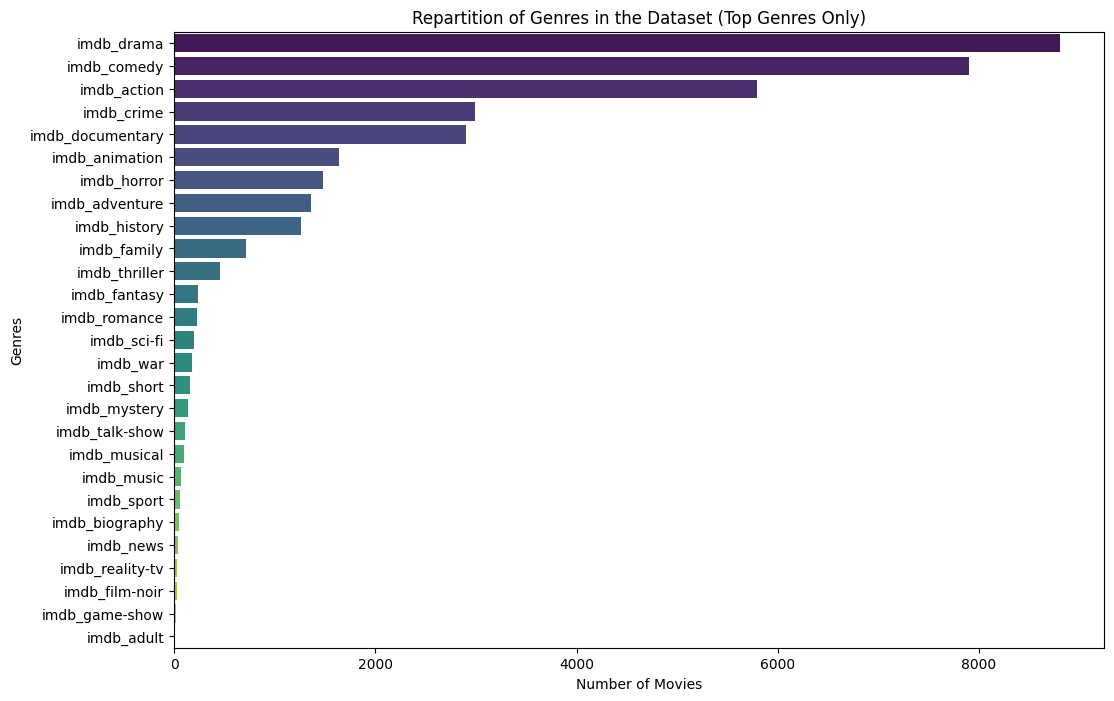

In [12]:
genre_top_counts = df_add_to_top["genre"].value_counts().sort_values(ascending=False)
genre_top_counts = genre_top_counts.drop('imdb_id')
genre_top_counts = genre_top_counts.filter(like='imdb_')

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_top_counts.values, y=genre_top_counts.index, palette="viridis")
plt.xlabel('Number of Movies')
plt.ylabel('Genres')
plt.title('Repartition of Genres in the Dataset (Top Genres Only)')
plt.show()

In [16]:
print("Après : ")
print(genre_top_counts[genre_top_counts >= genre_counts_quartiles[0.75]])
# print(genre_top_counts[genre_top_counts < genre_counts_quartiles[0.75]])
print("Avant : ")
print(genre_counts_only_first[genre_counts_only_first >= genre_counts_quartiles[0.75]])

Après : 
genre
imdb_drama          8802
imdb_comedy         7902
imdb_action         5797
imdb_crime          2989
imdb_documentary    2897
imdb_animation      1641
imdb_horror         1483
imdb_adventure      1364
Name: count, dtype: int64
Avant : 
imdb_drama          7806
imdb_comedy         7690
imdb_action         5764
imdb_documentary    2891
imdb_crime          2780
imdb_animation      1581
imdb_adventure      1348
dtype: int64


In [57]:
# Split genre_count into quartiles
genre_counts_quartiles = genre_counts_only_first.quantile([0.25, 0.5, 0.75])

# Select genres that are in the top quartile
least_genres = genre_counts_only_first[genre_counts_only_first < genre_counts_quartiles[0.75]].index
df_add_to_least = df.copy()

def sort_least(least_genres, df):
    least_genres = least_genres.sort_values(ascending=True, key=lambda x: df[x].count())
    return least_genres
least_genres = sort_least(least_genres, df_add_to_top)
least_genres

Index(['imdb_adult', 'imdb_reality-tv', 'imdb_film-noir', 'imdb_news',
       'imdb_game-show', 'imdb_sport', 'imdb_talk-show', 'imdb_short',
       'imdb_biography', 'imdb_western', 'imdb_mystery', 'imdb_music',
       'imdb_musical', 'imdb_fantasy', 'imdb_war', 'imdb_history',
       'imdb_family', 'imdb_sci-fi', 'imdb_romance', 'imdb_thriller',
       'imdb_horror'],
      dtype='object')

In [65]:
least_genres
def add_to_least_genres(row):
    global least_genres
    if row["genre"] not in least_genres:
        for g_least in least_genres:
            if isinstance(row[g_least], float) and float(row[g_least]) >= 1:
                row["genre"] = g_least
                least_genres = sort_least(least_genres, df_add_to_top)
                break
    return row

df_add_to_least = df_add_to_least.apply(add_to_least_genres, axis=1)
df_add_to_least["genre"].value_counts()

genre
imdb_horror         6724
imdb_romance        2917
imdb_thriller       2591
imdb_history        2225
imdb_fantasy        1927
imdb_family         1920
imdb_sci-fi         1906
imdb_biography      1692
imdb_war            1611
imdb_musical        1522
imdb_drama          1442
imdb_mystery        1426
imdb_comedy         1412
imdb_music          1343
imdb_short          1201
imdb_talk-show       920
imdb_sport           755
imdb_documentary     688
imdb_game-show       565
imdb_news            564
imdb_action          515
imdb_film-noir       381
imdb_crime           279
imdb_western         272
imdb_id              259
imdb_reality-tv      122
imdb_adventure       101
imdb_animation        63
imdb_adult             1
Name: count, dtype: int64

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_70571/3322057529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_least_counts.values, y=genre_least_counts.index, palette="viridis")


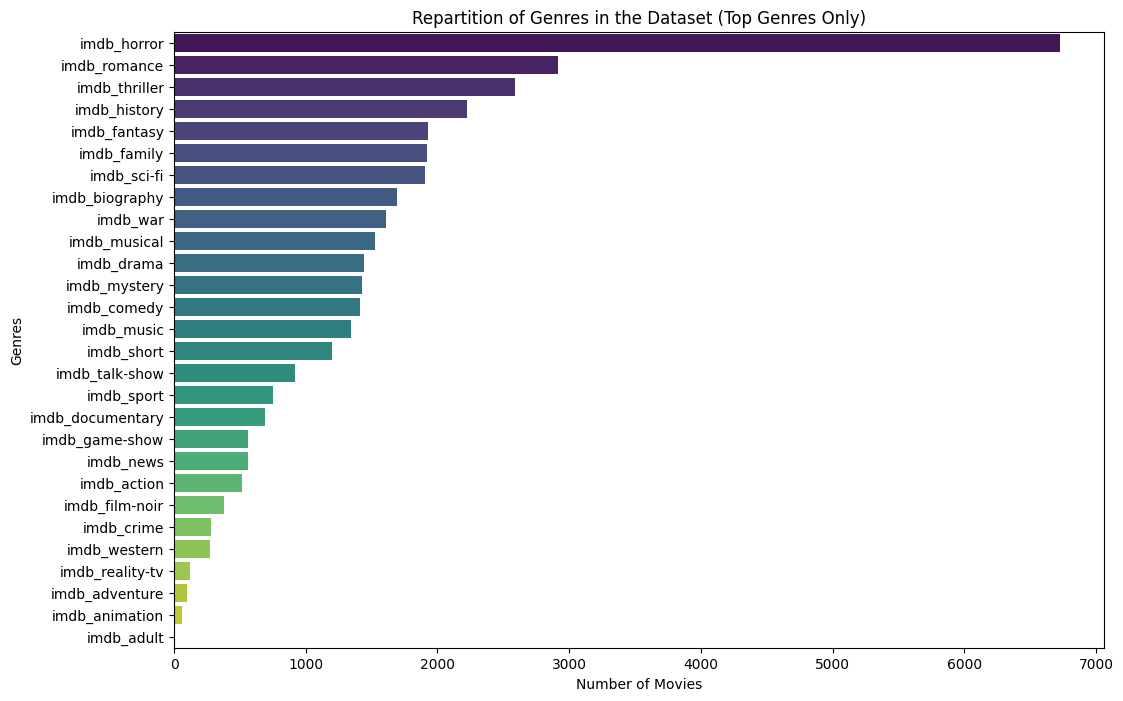

In [66]:
genre_least_counts = df_add_to_least["genre"].value_counts().sort_values(ascending=False)
genre_least_counts = genre_least_counts.drop('imdb_id')
genre_least_counts = genre_least_counts.filter(like='imdb_')

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_least_counts.values, y=genre_least_counts.index, palette="viridis")
plt.xlabel('Number of Movies')
plt.ylabel('Genres')
plt.title('Repartition of Genres in the Dataset (Top Genres Only)')
plt.show()

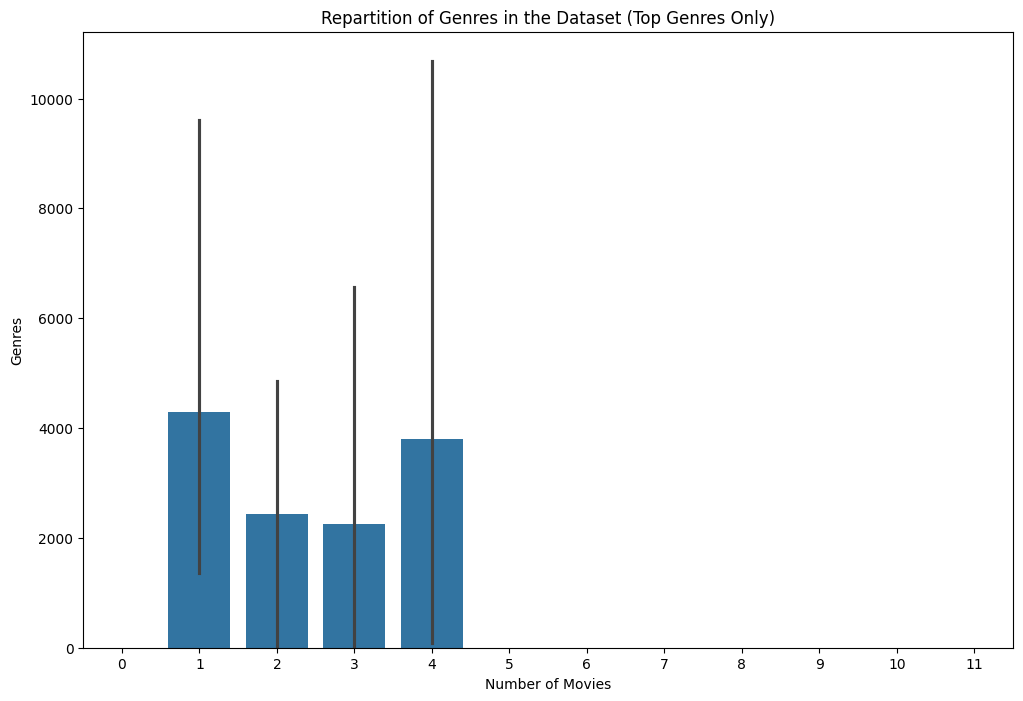

In [ ]:
df["genre_count"] = df.filter(regex='^imdb_(?!id$)').count(axis=1)

test = df["genre_count"].value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=df["genre_count"], y=df["genre_count"].value_counts())
plt.xlabel('Number of genres')
plt.ylabel('Number of movies')
plt.title('Repartition of Genres in the Dataset (Top Genres Only)')
plt.show()

## Training and test sets

In [41]:
X = df['Script']
y = df['genre']

In [ ]:
# Remove classes with fewer than 2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X_filtered = X[y.isin(valid_classes)]
y_filtered = y[y.isin(valid_classes)]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered.values)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

8120        imdb_action
1425     imdb_biography
8553       imdb_mystery
5678         imdb_drama
24566       imdb_action
              ...      
31347       imdb_horror
9941        imdb_action
21533        imdb_drama
27615    imdb_film-noir
10550        imdb_crime
Name: genre, Length: 15065, dtype: object

## Tokenization functions

In [21]:
def lemma_tokenize(doc):
    wnl = WordNetLemmatizer()
    return [wnl.lemmatize(t) for t in word_tokenize(doc)]

def char_tokenize(doc):
    return [char for char in doc]

def byte_tokenize(doc):
    tokens = doc.encode("utf-8")
    tokens = list(map(int, tokens))
    return [str(token) for token in tokens]

def gpt_tokenize(doc):
    enc = tiktoken.encoding_for_model("gpt-4")
    tokens = enc.encode(doc)
    return [str(token) for token in tokens]

## Training: Bag of Words (CountVectorizer) and Naive Bayes (MultinomialNB)

https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html

https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [23]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB())
#model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = en_stop), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=word_tokenize, ngram_range = (1,1)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=lemma_tokenize, ngram_range = (1,1)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=char_tokenize, ngram_range = (1,1)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=char_tokenize, ngram_range = (2,2)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=char_tokenize, ngram_range = (3,3)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=byte_tokenize, ngram_range = (1,1)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=byte_tokenize, ngram_range = (2,2)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=byte_tokenize, ngram_range = (3,3)), MultinomialNB())
#model = make_pipeline(CountVectorizer(tokenizer=gpt_tokenize, ngram_range = (1,1)), MultinomialNB())

In [54]:
model.fit(X_train, y_train)
#model.fit(X_train, y_train, multinomialnb__sample_weight=sample_weights)

y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Features dimension: (15065, 339796)
Classification Report:
                   precision    recall  f1-score   support

     imdb_action       0.48      0.65      0.55       549
  imdb_adventure       0.39      0.07      0.12       126
  imdb_animation       0.77      0.44      0.56       156
  imdb_biography       0.39      0.10      0.16       135
     imdb_comedy       0.39      0.68      0.50       788
      imdb_crime       0.38      0.25      0.30       285
imdb_documentary       0.75      0.76      0.75       298
      imdb_drama       0.41      0.42      0.42       791
     imdb_family       0.00      0.00      0.00        83
    imdb_fantasy       0.00      0.00      0.00        20
  imdb_film-noir       0.00      0.00      0.00         4
  imdb_game-show       0.00      0.00      0.00         2
    imdb_history       0.00      0.00      0.00         3
     imdb_horror       0.35      0.33      0.34       230
         imdb_id       0.00      0.00      0.00        80
      imdb_

/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

## Plot confusion matrix

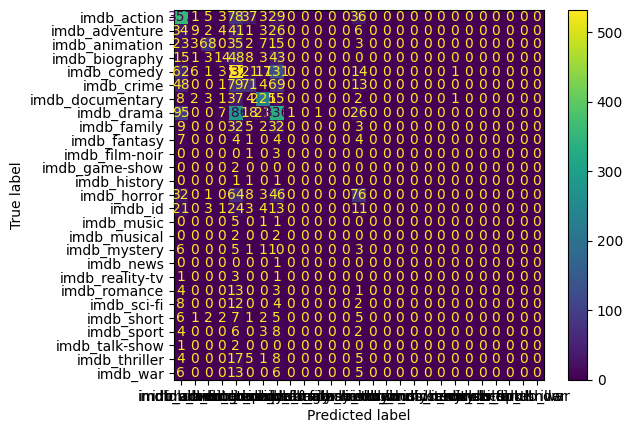

In [55]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
plt.show()

## Cross validation
https://scikit-learn.org/stable/modules/cross_validation.html

In [40]:
# Perform cross-validation and print the mean accuracy
scoring = 'f1_macro'
scores = cross_val_score(model, X, y, cv=5, scoring=scoring, n_jobs = -1)
print(f"Mean {scoring}: {scores.mean()}")
print(f"Standard deviation {scoring}: {scores.std()}")

Mean f1_macro: 0.40828471010718187
Standard deviation f1_macro: 0.01451110152051428


# Naive Bayes from scratch

In [102]:
y_train.head()

1040     happiness
25797         fear
16279         fear
1840         anger
26616         fear
Name: emotion, dtype: object

### Calculate priors and vocabulary

In [103]:
from collections import Counter

count_c = Counter(y_train)

priors = {k:v/len(y_train) for k, v in count_c.items()}
print(priors)

train_strings = " ".join(X_train)
train_tokens = word_tokenize(train_strings)
vocabulary = set(train_tokens)
V = len(vocabulary)
classes = set(y_train)

{'happiness': 0.1820796460176991, 'fear': 0.3911504424778761, 'anger': 0.14115044247787611, 'confusion': 0.18871681415929203, 'sadness': 0.09690265486725663}


### Calculate likelihoods 

In [104]:
train_df = pd.DataFrame(zip(X_train, y_train), columns = ["document", "emotion"])
train_df.head()

,document,emotion
0,a man gets out of prison. he's walking around ...,happiness
1,another the agency dream. at first i was outs...,fear
2,"i was at memorial stadium, supposed to do a dj...",fear
3,"i am driving my van, but can't find the keys t...",anger
4,there are four of us and we were trying to ste...,fear


In [113]:
mega_dict = dict()
prob_dict = dict()
k = 1

for c in classes:
    class_df = train_df.query(f"emotion == '{c}'")
    mega_document = class_df["document"]
    mega_strings = " ".join(mega_document)
    mega_tokens = word_tokenize(mega_strings)
    mega_count = Counter(mega_tokens)
    mega_dict[c] = mega_count
    prob_dict[c] = dict()
    

    for token in vocabulary:
        prob_dict[c][token] = (mega_dict[c][token] + k ) / (len(mega_tokens) + V)

print(mega_dict["anger"]["i"])
print(prob_dict["anger"]["i"])

7036
0.04408346854268335


### Prediction

In [114]:
import math

test_tokens = word_tokenize("i don't like it")

pred_dict = dict()

for c in classes:
    sum = math.log2(priors[c])
    for token in test_tokens:
        #print(prob_dict[c][token])
        sum += math.log2(prob_dict[c][token])
    sum = math.pow(2, sum)
    pred_dict[c] = sum
print(pred_dict)
print(max(pred_dict, key=pred_dict.get))

{'anger': 3.8438023650338485e-12, 'happiness': 5.738926582807367e-12, 'confusion': 7.1664344130907345e-12, 'sadness': 2.4003655911873422e-12, 'fear': 2.254136682259967e-11}
fear


In [115]:
import math

test_tokens = [word_tokenize(text) for text in X_test]

pred_dict = dict()
preds = list()

for report_tokens in test_tokens:
    for c in classes:
        sum = math.log2(priors[c])
        for token in report_tokens:
            if token in prob_dict[c]: # remove unknown tokens
                sum += math.log2(prob_dict[c][token])
        sum = math.pow(2, sum)
        pred_dict[c] = sum
    preds.append(max(pred_dict, key=pred_dict.get))

### Evaluation

In [116]:
from sklearn.metrics import classification_report

print(classification_report(preds, list(y_test)))

              precision    recall  f1-score   support

       anger       0.75      0.18      0.30       754
   confusion       0.10      0.53      0.17        38
        fear       0.33      0.54      0.41       262
   happiness       0.21      0.53      0.30        72
     sadness       0.03      1.00      0.06         4

    accuracy                           0.30      1130
   macro avg       0.28      0.56      0.25      1130
weighted avg       0.59      0.30      0.32      1130

